In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler, LabelEncoder
import mne


In [121]:
# Load dataset
data = pd.read_csv('data/shivansh_five_class_run_2.csv', header=None)
print(data.head())

              0         1         2      3           4           5   \
0  11:33:45.0180  left_arm  baseline  train  425719.562  525074.625   
1  11:33:45.0180  left_arm  baseline  train  672440.125   84625.945   
2  11:33:45.0180  left_arm  baseline  train  -55641.184  234758.328   
3  11:33:45.0180  left_arm  baseline  train -315912.344  600326.312   
4  11:33:45.0207  left_arm  baseline  train -750000.125  612271.438   

           6           7           8           9   ...          11     12  \
0  180933.719  502485.656  736399.562   11888.982  ...  548634.938 -0.006   
1 -145200.156  170589.953  651206.125 -496228.875  ...  308433.781 -0.013   
2  162108.531  109228.953  616567.438 -510549.281  ...  425647.344 -0.016   
3  372382.594   -9835.752  602904.625 -225798.047  ...  589045.312 -0.017   
4  305689.531  -23678.277  687282.375 -180928.172  ...  662890.000 -0.016   

      13     14   15   16   17      18   19   20  
0  0.982 -0.150  0.0  0.0  0.0  93.333  1.0  1.0  
1  0.996

In [122]:
MI = data[data.iloc[:, 2] == 'mi']
print(f'MI Readings shape: {MI.shape}')
print(MI[:5])

MI Readings shape: (402624, 21)
                0         1   2      3           4           5           6   \
504  11:33:47.0226  left_arm  mi  train  286106.469  262982.312  340737.250   
505  11:33:47.0226  left_arm  mi  train  286127.906  263003.594  340752.438   
506  11:33:47.0226  left_arm  mi  train  286148.031  263027.031  340771.031   
507  11:33:47.0226  left_arm  mi  train  286165.469  263044.375  340780.438   
508  11:33:47.0232  left_arm  mi  train  286186.906  263062.875  340789.812   

             7           8           9   ...          11     12     13     14  \
504  339969.250  280183.781  280335.688  ...  275631.250 -0.023  1.003 -0.163   
505  339989.094  280206.219  280359.562  ...  275657.469 -0.022  1.001 -0.165   
506  340010.719  280227.062  280387.094  ...  275688.938 -0.021  1.001 -0.164   
507  340019.125  280245.188  280402.750  ...  275706.188 -0.019  1.000 -0.163   
508  340028.344  280266.656  280417.656  ...  275720.312 -0.017  0.999 -0.165   

      

In [123]:
readings = MI.iloc[:, 4:12].values
labels = MI.iloc[:, 1].values
split = MI.iloc[:, 3].values
excution_label = MI.iloc[:, 2].values
print(f'Readings shape: {readings.shape}, Labels shape: {labels.shape}')
print(f'Unique labels: {np.unique(labels)}')
print(f'Labels distribution:\n{pd.Series(labels).value_counts()}')
print(readings[:5])

Readings shape: (402624, 8), Labels shape: (402624,)
Unique labels: ['left_arm' 'left_leg' 'right_arm' 'right_leg' 'still']
Labels distribution:
left_leg     80720
right_leg    80516
still        80472
left_arm     80464
right_arm    80452
dtype: int64
[[286106.469 262982.312 340737.25  339969.25  280183.781 280335.688
  260439.953 275631.25 ]
 [286127.906 263003.594 340752.438 339989.094 280206.219 280359.562
  260463.641 275657.469]
 [286148.031 263027.031 340771.031 340010.719 280227.062 280387.094
  260486.797 275688.938]
 [286165.469 263044.375 340780.438 340019.125 280245.188 280402.75
  260504.047 275706.188]
 [286186.906 263062.875 340789.812 340028.344 280266.656 280417.656
  260525.781 275720.312]]


In [124]:
# X_train = readings[split == 'train']
# y_train = labels[split == 'train']
# X_test = readings[split == 'test']
# y_test = labels[split == 'test']
# print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

In [125]:

def bandpass_filter(signal, lowcut=4, highcut=40, fs=250, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)
    return filtered


In [126]:


# Verify shape: (n_samples, n_channels)
print("readings.shape:", readings.shape)

fs = 250  # sampling frequency (Hz) - keep this consistent with your data

filtered_readings = np.zeros_like(readings)
for ch_idx in range(readings.shape[1]):  # loop over 8 channels
    raw_signal = readings[:, ch_idx]
    filtered_readings[:, ch_idx] = bandpass_filter(raw_signal, lowcut=4, highcut=40, fs=fs, order=4)

print("filtered_readings shape:", filtered_readings.shape)

readings.shape: (402624, 8)
filtered_readings shape: (402624, 8)


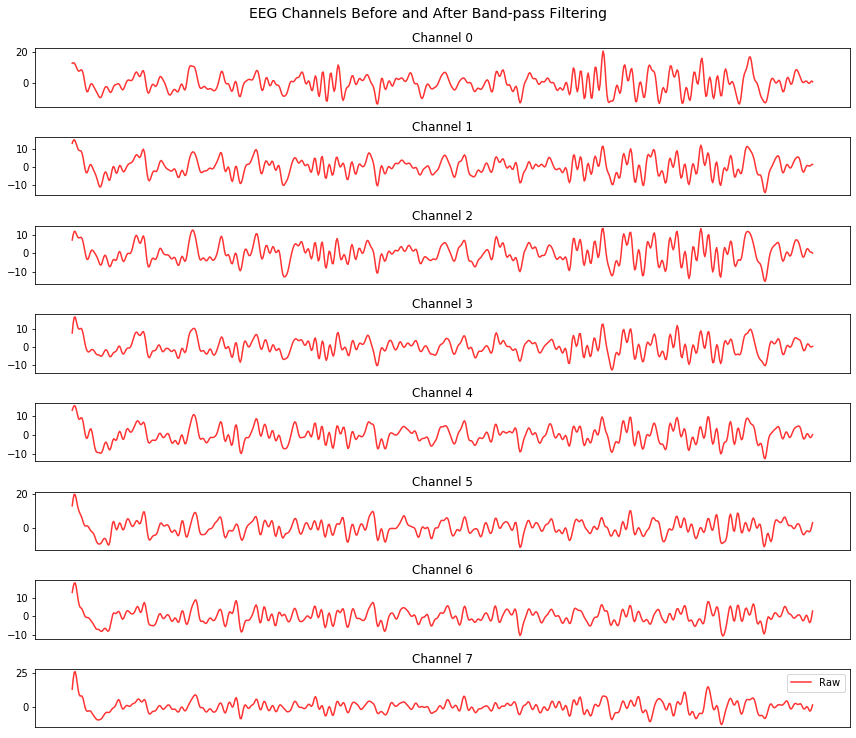

In [127]:
plt.figure(figsize=(12, 10))
for i in range(readings.shape[1]):
    plt.subplot(8, 1, i+1)
    plt.plot(filtered_readings[:750, i], color='red', alpha=0.8, label='Filtered')
    plt.title(f"Channel {i}")
    plt.xticks([])
    plt.tight_layout()

plt.legend(['Raw', 'Filtered'], loc='upper right')
plt.suptitle("EEG Channels Before and After Band-pass Filtering", fontsize=14, y=1.02)
plt.show()



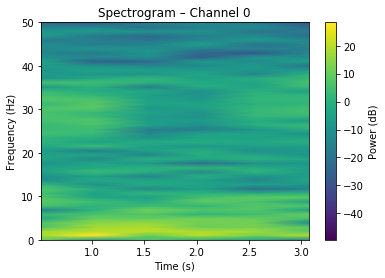

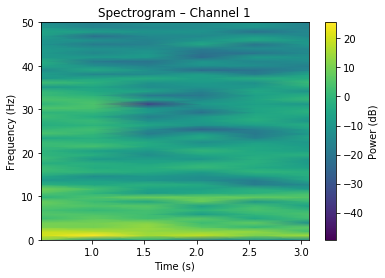

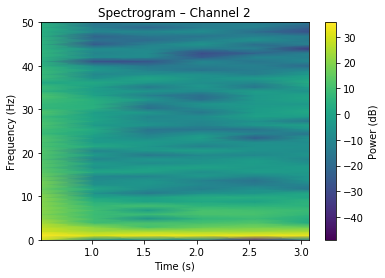

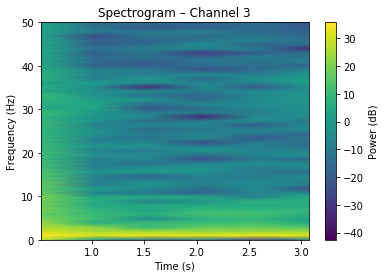

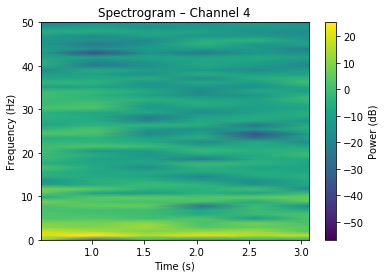

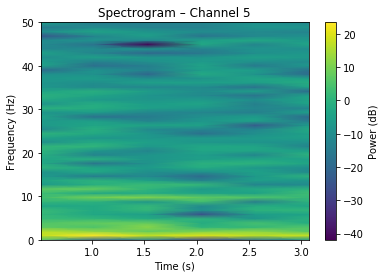

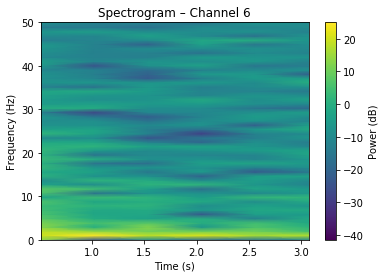

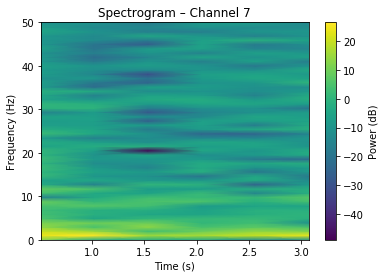

In [128]:
from scipy.signal import spectrogram

ch = 0
for i in range(readings.shape[1]):
    f, t, Sxx = spectrogram(readings[4000:5000, i], fs, nperseg=256, noverlap=128)
    plt.pcolormesh(t, f, 10*np.log10(Sxx), shading='gouraud')
    plt.title(f"Spectrogram – Channel {i}")
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (s)')
    plt.ylim(0, 50)
    plt.colorbar(label='Power (dB)')
    plt.show()




filtered_readings shape: (402624, 8)
Creating RawArray with float64 data, n_channels=8, n_times=402624
    Range : 0 ... 402623 =      0.000 ...  1610.492 secs
Ready.
Fitting ICA...
Fitting ICA to data using 8 channels (please be patient, this may take a while)
Inferring max_pca_components from picks
Selection by number: 8 components


c:\Anaconda\envs\torch37\lib\site-packages\mne\utils\check.py:78: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  this_version = LooseVersion(library.__version__)


Fitting ICA took 1.8s.


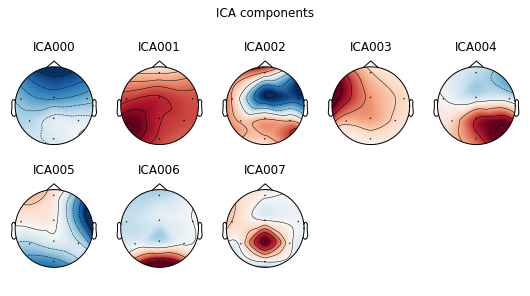

Transforming to ICA space (8 components)
Zeroing out 1 ICA components
filtered_clean shape: (402624, 8)


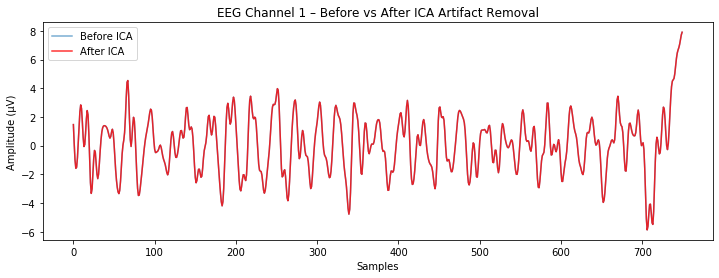

In [129]:
import mne


fs = 250
# Use realistic EEG channel names if possible
ch_names = ['Fz','C3','Cz','C4','P3','Pz','P4','Oz']
ch_types = ['eeg'] * 8
info = mne.create_info(ch_names=ch_names, sfreq=fs, ch_types=ch_types)

print("filtered_readings shape:", filtered_readings.shape)
raw_mne = mne.io.RawArray(filtered_readings.T, info)

# ✅ Add montage to provide electrode positions
montage = mne.channels.read_montage('standard_1020')
raw_mne.set_montage(montage)
# --- Run ICA ---
ica = mne.preprocessing.ICA(n_components=8, random_state=42, max_iter=500)
print("Fitting ICA...")
ica.fit(raw_mne)

# --- Visualize components safely ---
ica.plot_components()  # now works, shows scalp maps
# OR if you only want time-series of activations:
# ica.plot_sources(raw_mne)

# --- Optionally exclude components ---
ica.exclude = [0]  # change after visual inspection
raw_clean = ica.apply(raw_mne)

filtered_clean = raw_clean.get_data().T
print("filtered_clean shape:", filtered_clean.shape)

# --- Quick comparison ---
plt.figure(figsize=(12, 4))
plt.plot(filtered_readings[4250:5000, 0], label='Before ICA', alpha=0.6)
plt.plot(filtered_clean[4250:5000, 0], label='After ICA', color='red', alpha=0.8)
plt.title('EEG Channel 1 – Before vs After ICA Artifact Removal')
plt.xlabel('Samples')
plt.ylabel('Amplitude (µV)')
plt.legend()
plt.show()

In [130]:

scaler = StandardScaler()
eeg_norm = scaler.fit_transform(filtered_clean)  # shape: (n_samples, 8)

print("eeg_norm shape:", eeg_norm)

eeg_norm shape: [[ 0.60108771  1.46786056  0.04028657 ...  2.180887    2.79054523
   2.37322008]
 [-0.39785383  1.51027827  0.26406871 ...  2.94922268  3.44895626
   3.852938  ]
 [-1.05734232  1.49328577  0.40471323 ...  3.38059093  3.880837
   4.81118002]
 ...
 [ 0.49908103  0.58274835  0.35013376 ...  0.86652602 -0.1142839
   1.24820126]
 [ 0.17794769  0.25410076  0.13098481 ...  0.52360638 -0.13425979
   0.71733469]
 [ 0.04183018  0.0317981  -0.1413806  ...  0.13644643  0.04211903
  -0.10116718]]


In [131]:
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

In [132]:
# -------------------------------
def create_epochs(eeg_array, labels_array, stride, window, amp_thresh=150):
    X, y = [], []
    for start in range(0, len(eeg_array) - window, stride):
        end = start + window
        epoch = eeg_array[start:end, :]
        epoch_labels = labels_array[start:end]
        # majority label in the window
        majority = np.bincount(epoch_labels).argmax()
        purity = np.mean(epoch_labels == majority)
        if purity >= 0.9 and np.max(np.abs(epoch)) < amp_thresh:
            X.append(epoch)
            y.append(majority)
    return np.array(X), np.array(y)

In [133]:
train_idx = np.where(split == 'train')[0]
test_idx  = np.where(split == 'test')[0]

eeg_train, lbl_train = eeg_norm[train_idx], labels_encoded[train_idx]
eeg_test,  lbl_test  = eeg_norm[test_idx],  labels_encoded[test_idx]
print("Train samples:", eeg_train.shape[0])
print("Test samples :", eeg_test.shape[0])

Train samples: 377516
Test samples : 25108


In [135]:
window_sec = 1
window_size = fs * window_sec          # 250 samples per 1 s
train_stride = window_size // 2        # 50 % overlap
test_stride  = window_size             # no overlap
amp_thresh = 150   

X_train, y_train = create_epochs(eeg_train, lbl_train,
                                 stride=train_stride, window=window_size)
X_test, y_test = create_epochs(eeg_test, lbl_test,
                               stride=test_stride, window=window_size)

print("Train epochs:", X_train.shape, "Test epochs:", X_test.shape)

Train epochs: (2534, 250, 8) Test epochs: (87, 250, 8)


In [139]:
def normalize_epoch(epoch):
    mean = epoch.mean(axis=0, keepdims=True)
    std = epoch.std(axis=0, keepdims=True) + 1e-8
    return (epoch - mean) / std

X_train = np.array([normalize_epoch(e) for e in X_train])
X_test  = np.array([normalize_epoch(e) for e in X_test])

# --- Reshape for CTNet ---
X_train_ctnet = np.transpose(X_train, (0, 2, 1))  # (N, 8, 250)
X_test_ctnet  = np.transpose(X_test,  (0, 2, 1))


print("CTNet train shape:", X_train_ctnet.shape)
print("CTNet test shape:", X_test_ctnet.shape)

CTNet train shape: (2534, 8, 250)
CTNet test shape: (87, 8, 250)


In [140]:
np.save("X_train_ctnet.npy", X_train_ctnet)
np.save("y_train_ctnet.npy", y_train)
np.save("X_test_ctnet.npy",  X_test_ctnet)
np.save("y_test_ctnet.npy",  y_test)